##### For the human survey results

In [43]:
#importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error)

In [44]:
#loading the data

df = pd.read_csv('survey_results.csv')
df.head(5)

,User ID,ID,Data Provider,Project Name,Consumer Team,Consumer Name,Consumer Description,Variation Type,Variation Value,Purpose,AI Final Decision,Human Expert: Seniority,Human Expert: Hastiness (1: Very Hasty | 7: Very Formal),Human Expert: Meaning Preservation (1: Very Different | 7: Very Similar),Time on Question (seconds),Total Elapsed Time (seconds)
0,user_777,3e6df138892d6908a28f951eec68f5cc902c778c4db63e...,Marketing Campaigns,Policy Customization Algorithm,contracts,Custom Policy Advisor,Enhances the customer interaction experience b...,combined,"junior analyst + very hasty (typos, shorthand,...",hey can i get access to the marketing campaign...,Reject,Senior Manager,7,7,7.27,7.38
1,user_777,569aece891f2a8d3ee80645eba515c0af80c714bb4036f...,Payments,AI-driven Customer Service Enhancements,enabling-team,AI Service Enhancer,Uses AI to anticipate and resolve customer iss...,combined,executive/CEO + very formal (precise legal-sty...,In order to enhance the experience of our cust...,Reject,Senior Manager,7,7,32.11,39.49
2,user_777,bd7b9717630b7177aecf10a02c0dcbdb02b9d42dce0a52...,Order Lines,Logistics Demand Forecasting,logistics,Demand Forecasting System,Enhances stock and resource allocation by pred...,combined,executive/CEO + neutral (standard professional...,The Logistics team intends to access the 'Orde...,Accept,Senior Manager,7,7,87.12,126.62
3,user_777,ab19af49dfaf765c37a9852fbfac73328cdbc036ac141b...,Actor,Automatic Claim Processing,claims--benefit,Automated Claims Handler,Streamlines the claim verification process by ...,combined,senior manager + neutral (standard professiona...,Our application needs access to actors' contac...,Accept,Senior Manager,7,7,147.18,273.80
4,user_777,5fbf5126f2e1e7a0840e4230d7079b429f84ebf0d88b5e...,Products,Product Performance Metrics,marketing,Product Success Evaluator,Analyzes product performance metrics to enhanc...,combined,"executive/CEO + very hasty (typos, shorthand, ...",need data on which items r hot reviews n retur...,Reject,Junior Analyst,1,1,80.08,353.88


In [45]:
#the information of the survey df
print(df.head())
print(df.shape)

    User ID                                                 ID  \
0  user_777  3e6df138892d6908a28f951eec68f5cc902c778c4db63e...   
1  user_777  569aece891f2a8d3ee80645eba515c0af80c714bb4036f...   
2  user_777  bd7b9717630b7177aecf10a02c0dcbdb02b9d42dce0a52...   
3  user_777  ab19af49dfaf765c37a9852fbfac73328cdbc036ac141b...   
4  user_777  5fbf5126f2e1e7a0840e4230d7079b429f84ebf0d88b5e...   

         Data Provider                             Project Name  \
0  Marketing Campaigns           Policy Customization Algorithm   
1             Payments  AI-driven Customer Service Enhancements   
2          Order Lines             Logistics Demand Forecasting   
3                Actor               Automatic Claim Processing   
4             Products              Product Performance Metrics   

     Consumer Team              Consumer Name  \
0        contracts      Custom Policy Advisor   
1    enabling-team        AI Service Enhancer   
2        logistics  Demand Forecasting System   
3  c

In [46]:
#seperating the original and the modified (combined) requests

original_requests = df[df["Variation Type"] == "none"].copy()

modified_requests = df[df["Variation Type"] == "combined"].copy()


print(f"Total survey responses: {len(df)}") 
print(f"Modified request responses: {len(modified_requests)}") 
print(f"Original request responses: {len(original_requests)}") 
print(f"Number of participants: {df['User ID'].nunique()}")

Total survey responses: 250
Modified request responses: 232
Original request responses: 18
Number of participants: 5


In [47]:
#renaming the columns

df = df.rename(columns={
    "Human Expert: Seniority": "Human Seniority",
    "Human Expert: Hastiness (1: Very Hasty | 7: Very Formal)": "Human Hastiness",
    "Human Expert: Meaning Preservation (1: Very Different | 7: Very Similar)": "Meaning Preservation"
})

In [48]:
#extracting the combined dimensions

modified_requests["Seniority"] = (modified_requests["Variation Value"]
    .str.extract(r"^(intern|junior analyst|senior manager|executive/CEO)",expand=False)
    .replace({
        "intern": "Intern",
        "junior analyst": "Junior Analyst",
        "senior manager": "Senior Manager",
        "executive/CEO": "Executive/CEO"
    })
)


modified_requests["Hastiness"] = (modified_requests["Variation Value"]
.str.extract(
    r"\+\s*(very hasty|neutral|very formal)",
    expand=False
)
.replace({
    "very hasty": "Very Hasty",
    "neutral": "Neutral",
    "very formal": "Very Formal"
})
)


#checking it 
display(modified_requests["Seniority"].value_counts())
display(modified_requests["Hastiness"].value_counts())

Seniority
Executive/CEO     72
Intern            61
Junior Analyst    54
Senior Manager    45
Name: count, dtype: int64

Hastiness
Very Hasty     80
Neutral        78
Very Formal    74
Name: count, dtype: int64

In [50]:
#convering the meaning preservation (for the ones that original to 0)

modified_requests = modified_requests.rename(columns={
    "Human Expert: Meaning Preservation (1: Very Different | 7: Very Similar)": "Meaning Preservation"
})
modified_requests["Meaning Preservation"] = pd.to_numeric(modified_requests["Meaning Preservation"],errors="coerce")

In [ ]:
#making the following summary table 

meaning_summary = pd.DataFrame({
    "Metric": [
        "Number of ratings",
        "Mean",
        "Median",
        "Standard deviation",
        "Minimum",
        "Maximum",
        "Ratings of 5 or higher (%)",
        "Ratings of 6 or higher (%)"
    ],
    "Value": [
        modified_requests["Meaning Preservation"].count(),
        round(modified_requests["Meaning Preservation"].mean(), 2),
        round(modified_requests["Meaning Preservation"].median(), 2),
        round(modified_requests["Meaning Preservation"].std(), 2),
        modified_requests["Meaning Preservation"].min(),
        modified_requests["Meaning Preservation"].max(),
        round((modified_requests["Meaning Preservation"] >= 5).mean() * 100,2),
        round((modified_requests["Meaning Preservation"] >= 6).mean() * 100,2)
    ]
})

display(meaning_summary)

,Metric,Value
0,Number of ratings,232.00
1,Mean,5.26
2,Median,6.00
3,Standard deviation,1.61
4,Minimum,1.00
5,Maximum,7.00
6,Ratings of 5 or higher (%),71.55
7,Ratings of 6 or higher (%),54.31


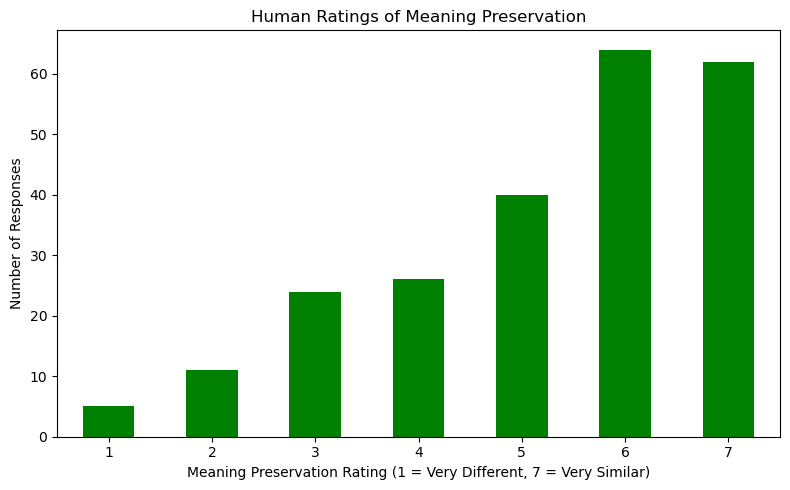

In [57]:
#plotting the meaning preservation

meaning_counts = (modified_requests["Meaning Preservation"].value_counts().sort_index())

plt.figure(figsize=(8, 5))
meaning_counts.plot(kind="bar",color = "green")

plt.xlabel("Meaning Preservation Rating (1 = Very Different, 7 = Very Similar)")
plt.ylabel("Number of Responses")
plt.title("Human Ratings of Meaning Preservation")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [60]:

#creating the intended scores for each seniority prompt
hastiness_scores = {"Very Hasty": 1,"Neutral": 4,"Very Formal": 7}
modified_requests["Hastiness Score"] = (modified_requests["Hastiness"].map(hastiness_scores))

In [70]:
hastiness_summary = (
    modified_requests
    .groupby("Hastiness")
    .agg(
        Number_of_Ratings=("Hastiness Score", "count"),
        Mean_Rating=("Hastiness Score", "mean"),
        Median_Rating=("Hastiness Score", "median"),
        Standard_Deviation=("Hastiness Score", "std")
    )
    .reset_index()
)

hastiness_summary[
    ["Mean_Rating", "Median_Rating", "Standard_Deviation"]
] = hastiness_summary[
    ["Mean_Rating", "Median_Rating", "Standard_Deviation"]
].round(2)

display(hastiness_summary)

,Hastiness,Number_of_Ratings,Mean_Rating,Median_Rating,Standard_Deviation
0,Neutral,78,4.0,4.0,0.0
1,Very Formal,74,7.0,7.0,0.0
2,Very Hasty,80,1.0,1.0,0.0


In [72]:
#calculating the hastiness agreement
modified_requests["Hastiness Difference"] = abs(modified_requests["Hastiness Score"]- modified_requests["Intended Hastiness Score"])

exact_hastiness_agreement = (modified_requests["Hastiness Difference"] == 0).mean() * 100

within_one_hastiness_agreement = (modified_requests["Hastiness Difference"] <= 1).mean() * 100

hastiness_mae = mean_absolute_error(modified_requests["Intended Hastiness Score"],modified_requests["Hastiness Score"])

print(f"Exact hastiness agreement: "f"{exact_hastiness_agreement:.2f}%")

print(f"Agreement within one scale point: "f"{within_one_hastiness_agreement:.2f}%")

print(f"Mean absolute error: "f"{hastiness_mae:.2f}")


KeyError: 'Intended Hastiness Score'

In [73]:
print(modified_requests[
    ["Hastiness Score", "Intended Hastiness Score"]
].dtypes)

KeyError: "['Intended Hastiness Score'] not in index"